### Prueba tecnica - Subocol IA (Especialista IA)

El objetivo de esta prueba es evaluar sus habilidades en el ciclo de vida de un proyecto de Inteligencia Artificial, centrándose en dos pilares fundamentales:

1.	Modelamiento: Diseño y entrenamiento de un modelo de clasificación.
2.	Despliegue: Creación de un servicio de inferencia para el consumo del modelo.

Acorde al PDF adjunto lea detenidamente y complete con el codigo necesario el desarollo de la prueba en este notebook, si requiere utilizar scripts adicionales para desplegar el servicio y el modelo, lo puede hacer. 

La idea de este notebook es verificar el tratamiento de los datos y el entrenamiento del modelo. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Explicacion de las columnas

- numero_aviso: id numerico del aviso (numero del incidente/siniestro).
- fecha_creacion: Fecha de creacion del aviso.
- tipo_carroceria: Tipo de carrocería del vehículo (ej: hatchback, sedán, SUV, etc.).
- marca: Fabricante del vehículo (ej: HYUNDAI).
- linea: Linea del vehículo (ej: GRAND I10 HB).
- version:	Variante específica de la linea, (ej: 1400 CC SEDAN).
- modelo: Año de fabricación del vehículo (ej: 2020).
- version_hechos: Descripción del incidente/aviso ocurrido (ej: "iba en la vía, me colisionan a un costado y le...").
- codigo_irs: Código identificador de la pieza/repuesto (ej: 06040006nddn).
- nombre_irs: Nombre descriptivo de la pieza afectada (ej: "rin sencillo delantero derecho", "cubre polvo...").
- piezas_totales: Cantidad total de piezas involucradas en el aviso.
- piezas_cambio: Cantidad de piezas que requieren cambio/reemplazo.
- estado_aviso: estado entregado u objetado

In [3]:
# Lectura dataset
version_piezas = pd.read_csv("./data/dataset_pt.csv", low_memory=False, sep=';')

In [4]:
version_piezas.head()

,numero_aviso,fecha_creacion,tipo_carroceria,marca,linea,version,modelo,version_hechos,codigo_irs,nombre_irs,piezas_totales,piezas_cambio,estado_aviso
0,237305,2025-01-03 10:10:18.421101,pickup,VOLKSWAGEN,AMAROK,POWER PLUS 4X4 2.0 AUT,2016,maquinaria motoniveladora me choco en reversa ...,02090112nndn,parachoque del.,13,13,ENTREGADO
1,237305,2025-01-03 10:10:18.421101,pickup,VOLKSWAGEN,AMAROK,POWER PLUS 4X4 2.0 AUT,2016,maquinaria motoniveladora me choco en reversa ...,02030014nnnn,broche carroceria,13,13,ENTREGADO
2,237305,2025-01-03 10:10:18.421101,pickup,VOLKSWAGEN,AMAROK,POWER PLUS 4X4 2.0 AUT,2016,maquinaria motoniveladora me choco en reversa ...,03040008nndn,ampolleta.,13,13,ENTREGADO
3,237305,2025-01-03 10:10:18.421101,pickup,VOLKSWAGEN,AMAROK,POWER PLUS 4X4 2.0 AUT,2016,maquinaria motoniveladora me choco en reversa ...,02090129nndn,mascara del. central,13,13,ENTREGADO
4,237305,2025-01-03 10:10:18.421101,pickup,VOLKSWAGEN,AMAROK,POWER PLUS 4X4 2.0 AUT,2016,maquinaria motoniveladora me choco en reversa ...,02010229nndn,tapa de neblinero delantero izquierdo,13,13,ENTREGADO


### Agregar por aviso

El dataset viene en formato **largo**: una fila por pieza afectada. El dictamen (`estado_aviso`) aplica al **siniestro completo** (`numero_aviso`), no a cada pieza.

Por eso consolidamos la información en **un registro por aviso**, uniendo:
- el relato del asegurado (`version_hechos`)
- la lista de piezas afectadas (`nombre_irs`)
- los metadatos del vehículo
- el dictamen final (`estado_aviso`)

In [5]:
# Verificar que cada aviso tiene un solo dictamen
dictamenes_por_aviso = version_piezas.groupby("numero_aviso")["estado_aviso"].nunique()
assert dictamenes_por_aviso.max() == 1, "Hay avisos con más de un dictamen"

print(f"Filas en dataset original: {len(version_piezas):,}")
print(f"Avisos únicos: {version_piezas['numero_aviso'].nunique():,}")
print(f"Promedio de piezas por aviso: {len(version_piezas) / version_piezas['numero_aviso'].nunique():.1f}")

Filas en dataset original: 7,532
Avisos únicos: 800
Promedio de piezas por aviso: 9.4


In [6]:
def agregar_por_aviso(df: pd.DataFrame) -> pd.DataFrame:
    """Consolida el dataset de piezas en un registro por siniestro."""
    return (
        df.groupby("numero_aviso", as_index=False)
        .agg(
            fecha_creacion=("fecha_creacion", "first"),
            tipo_carroceria=("tipo_carroceria", "first"),
            marca=("marca", "first"),
            linea=("linea", "first"),
            version=("version", "first"),
            modelo=("modelo", "first"),
            version_hechos=("version_hechos", "first"),
            piezas_totales=("piezas_totales", "first"),
            piezas_cambio=("piezas_cambio", "first"),
            piezas=(
                "nombre_irs",
                lambda x: sorted(set(x.dropna().astype(str))),
            ),
            codigos_irs=(
                "codigo_irs",
                lambda x: sorted(set(x.dropna().astype(str))),
            ),
            num_piezas_registradas=("nombre_irs", "nunique"),
            estado_aviso=("estado_aviso", "first"),
           
        )
        .assign(
            piezas_texto=lambda d: d["piezas"].apply(lambda p: ", ".join(p)),
            vehiculo=lambda d: (
                d["tipo_carroceria"].astype(str)
                + " "
                + d["marca"].astype(str)
                + " "
                + d["linea"].astype(str)
                + " "
                + d["modelo"].astype(str)
            ),
        )
    )

avisos = agregar_por_aviso(version_piezas)
avisos.head()

,numero_aviso,fecha_creacion,tipo_carroceria,marca,linea,version,modelo,version_hechos,piezas_totales,piezas_cambio,piezas,codigos_irs,num_piezas_registradas,estado_aviso,piezas_texto,vehiculo
0,75886,2023-08-07 11:24:21.597000,utilitario,TOYOTA,HIACE,[1],2022,baje la velocidad por el peaje y el auto me go...,25,25,"[base portalampara trasero derecho, base porta...","[02020004ennn, 02020030nntn, 02030019endn, 020...",25,OBJETADO,"base portalampara trasero derecho, base portal...",utilitario TOYOTA HIACE 2022
1,76221,2023-08-09 05:32:53.474000,NaN,NISSAN,NP 300 FRONTIER [2],2.5L MT 2500CC TD 4X2 AA 2AB ABS,2019,ubicacion: ladera choconta hechos: iba subiend...,26,24,"[barra antivuelco, bisagra derecho tapa baul, ...","[02010001nnns, 02020005ednn, 02020006einn, 020...",22,OBJETADO,"barra antivuelco, bisagra derecho tapa baul, b...",NaN
2,77183,2023-08-15 17:06:49.222000,NaN,RAM,RAM [5],DT 1500 BIG HORN ETORQ CREW CAB HYBRID TP 3600...,2021,"ubicacion: santa ana magdalena- cicuco, boliva...",2,2,"[babero delantero, caja direccion mecanica]","[02090009nndn, 05070004nnni]",2,OBJETADO,"babero delantero, caja direccion mecanica",NaN
3,78558,2023-08-24 14:57:22.597000,sedan,HYUNDAI,ACCENT SOLARIS,SOLARIS,2019,iba en via principal y en san felipe el auto d...,16,16,[brazo refuerzo derecho soporte defensa traser...,"[02090111nntn, 02090112nndn, 02090113nntn, 020...",15,ENTREGADO,brazo refuerzo derecho soporte defensa trasero...,sedan HYUNDAI ACCENT SOLARIS 2019
4,78746,2023-08-25 14:26:39.104000,NaN,FORD,ESCAPE [3],TITANIUM TP 2000CC 4X4,2017,"ubicacion: cra 22 cll 29, cartagena hechos: es...",2,2,"[caja de direccion hidraulica, tornillo caja d...","[05020005innn, 05020008nndn]",2,OBJETADO,"caja de direccion hidraulica, tornillo caja de...",NaN


In [7]:
# Resumen del dataset agregado
print(f"Registros (avisos): {len(avisos):,}")
print("\nDistribución del target:")
print(avisos["estado_aviso"].value_counts())
print("\nEjemplo de un aviso consolidado:")
ejemplo = avisos.iloc[0]
print(f"  Aviso: {ejemplo['numero_aviso']}")
print(f"  Vehículo: {ejemplo['vehiculo']}")
print(f"  Dictamen: {ejemplo['estado_aviso']}")
print(f"  Piezas ({ejemplo['num_piezas_registradas']}): {ejemplo['piezas_texto'][:120]}...")
print(f"  Relato: {ejemplo['version_hechos'][:120]}...")

Registros (avisos): 800

Distribución del target:
estado_aviso
OBJETADO     500
ENTREGADO    300
Name: count, dtype: int64

Ejemplo de un aviso consolidado:
  Aviso: 75886
  Vehículo: utilitario TOYOTA HIACE 2022
  Dictamen: OBJETADO
  Piezas (25): base portalampara trasero derecho, base portalampara trasero izquierdo, brazo refuerzo derecho soporte defensa trasero, ...
  Relato: baje la velocidad por el peaje y el auto me golpea por atras....


### Split train / val / test

Particionamiento **estratificado** por `estado_aviso` (misma proporción ~62,5 % OBJETADO / 37,5 % ENTREGADO en cada conjunto).

| Conjunto | Uso |
|---|---|
| **Train (70 %)** | Indexar en Azure AI Search (corpus RAG) |
| **Val (15 %)** | Ajustar prompt, top-K, búsqueda híbrida, umbrales — **no se indexa** |
| **Test (15 %)** | Evaluación final — **no se indexa**, usar una sola vez |

In [8]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15 

# 1) Separar test (15 %)
train_val, test = train_test_split(
    avisos,
    test_size=TEST_SIZE,
    stratify=avisos["estado_aviso"],
    random_state=RANDOM_STATE,
)

# 2) Del resto, separar train (70 %) y val (15 %)
val_ratio_of_remainder = VAL_SIZE / (1 - TEST_SIZE)
train, val = train_test_split(
    train_val,
    test_size=val_ratio_of_remainder,
    stratify=train_val["estado_aviso"],
    random_state=RANDOM_STATE,
)

print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

Train: 559 | Val: 121 | Test: 120


In [10]:
def resumen_split(df: pd.DataFrame, nombre: str) -> pd.Series:
    dist = df["estado_aviso"].value_counts(normalize=True).mul(100).round(1)
    return pd.Series({
        "conjunto": nombre,
        "n": len(df),
        "OBJETADO": int((df["estado_aviso"] == "OBJETADO").sum()),
        "ENTREGADO": int((df["estado_aviso"] == "ENTREGADO").sum()),
        "% OBJETADO": dist.get("OBJETADO", 0),
        "% ENTREGADO": dist.get("ENTREGADO", 0),
    })

resumen_splits = pd.DataFrame([
    resumen_split(avisos, "total"),
    resumen_split(train, "train"),
    resumen_split(val, "val"),
    resumen_split(test, "test"),
])
resumen_splits

,conjunto,n,OBJETADO,ENTREGADO,% OBJETADO,% ENTREGADO
0,total,800,500,300,62.5,37.5
1,train,559,349,210,62.4,37.6
2,val,121,76,45,62.8,37.2
3,test,120,75,45,62.5,37.5


## Entrenamiento RAG con Azure

Pipeline: indexar **train** en Azure AI Search → clasificar **val/test** con retrieve + LLM → evaluar métricas.

| Paso | Qué hace | ¿Llama al LLM? |
|------|----------|----------------|
| Configuración | Lee `.env` y crea `settings` | No |
| Indexación | Sube ~559 avisos de train al índice | Embeddings |
| Inferencia val / test | Clasifica aviso a aviso | Sí |
| Persistencia / métricas | CSV y tablas de evaluación | No |

**Prioridad de negocio:** alto **recall en OBJETADO** (minimizar FN).

1. Copia `.env.example` → `.env` y completa endpoints/deployments.
2. Autenticación: `az login` (RBAC) **o** API keys en `.env`.
3. **Train** se indexa en Azure AI Search. **Val/Test no se indexan**.

### 4.1 Configuración

Carga variables de entorno y prepara el cliente de Azure (OpenAI + Search).

In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import AzureSettings

settings = AzureSettings.from_env()

### 4.2 Indexación del corpus (train)

Embeddings + subida de avisos de **train** al índice. Val y test **no** se indexan.

In [10]:
from src.indexer import index_train_corpus

indexed_count = index_train_corpus(
    train,
    settings,
    recreate_index=True,
    batch_size=16,
)

print(f"Documentos indexados (train): {indexed_count}")

Documentos indexados (train): 559


### 4.3 Inferencia — validation (121 avisos)

Clasifica cada aviso de val con búsqueda híbrida + LLM.  
`MAX_SAMPLES = None` evalúa todo val; usa un número pequeño para pruebas rápidas.

In [12]:
from src.evaluate import evaluate_dataframe

# Evaluación en val (usa max_samples para pruebas rápidas; None = todo val)
MAX_SAMPLES = None

val_results, val_metrics = evaluate_dataframe(
    val,
    settings=settings,
    max_samples=MAX_SAMPLES,
)

display(val_results)
print("Matriz de confusión [ENTREGADO, OBJETADO]:", val_metrics["confusion_matrix"])
print("Reporte OBJETADO:", val_metrics["classification_report"]["OBJETADO"])

,numero_aviso,dictamen_real,dictamen_pred,confianza,razones,casos_similares
0,231121,ENTREGADO,ENTREGADO,0.92,Versión de hechos coherente con las piezas afe...,"248917, 234887, 267277, 290098, 251403, 290593..."
1,181475,OBJETADO,OBJETADO,0.92,Patrón histórico: la mayoría de casos similare...,"170595, 251081, 152764, 91639, 254175, 176102,..."
2,112481,OBJETADO,OBJETADO,0.95,Presencia del patrón 'reversa en parqueadero' ...,"257472, 101652, 241336, 175757, 197479, 93390,..."
3,235615,OBJETADO,OBJETADO,0.95,"Mención explícita de un tercero reversando (""e...","248965, 218231, 234114, 99755, 181444, 112262,..."
4,86050,OBJETADO,OBJETADO,0.95,Inconsistencia entre relato y piezas: relato i...,"171877, 233596, 101645, 114056, 80796, 150014,..."
...,...,...,...,...,...,...
116,213628,OBJETADO,OBJETADO,0.75,La versión indica que un vehículo en sentido c...,"109193, 237012, 103483, 159550, 195299, 206866..."
117,131524,OBJETADO,OBJETADO,0.95,Inconsistencia entre relato y piezas: relato i...,"118271, 88734, 115975, 130854, 249336, 218536,..."
118,133876,OBJETADO,OBJETADO,0.95,Inconsistencia entre relato y piezas: versión ...,"141411, 106379, 87669, 224869, 126954, 186068,..."
119,262841,OBJETADO,OBJETADO,0.95,Mención explícita de tercero responsable en re...,"78558, 188544, 235888, 267063, 217784, 280270,..."


Matriz de confusión [ENTREGADO, OBJETADO]: [[5, 40], [2, 74]]
Reporte OBJETADO: {'precision': 0.6491228070175439, 'recall': 0.9736842105263158, 'f1-score': 0.7789473684210526, 'support': 76.0}


#### Gráficas — validation

- **Matriz de confusión** (heatmap): visualiza TN, FP, FN, TP.
- **Métricas por clase**: precision, recall y F1.
- **Confianza por resultado**: ¿los FN ocurren con alta confianza del modelo?

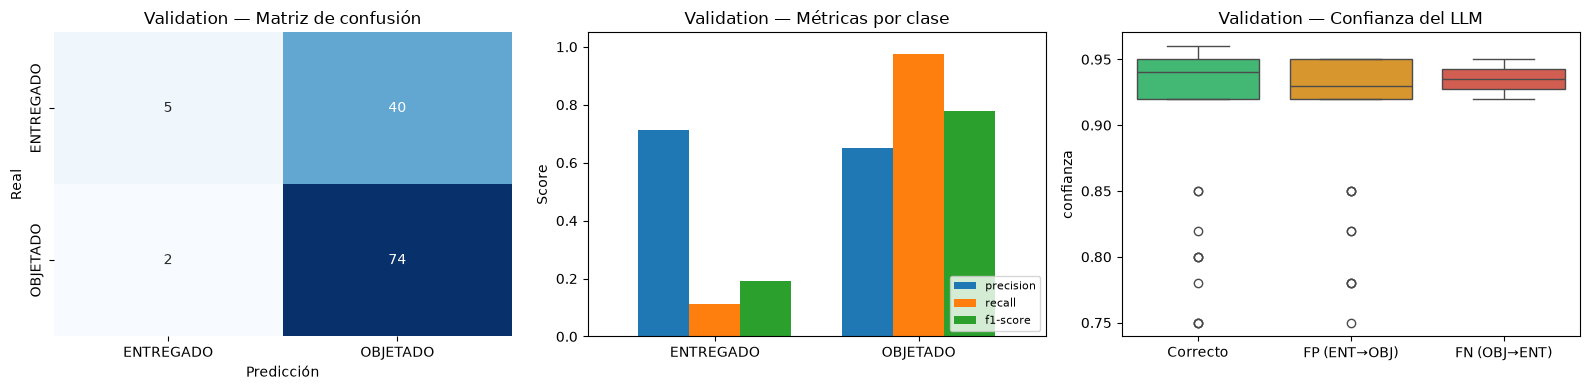

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

LABELS = ["ENTREGADO", "OBJETADO"]


def plot_rag_evaluation(results_df: pd.DataFrame, title: str) -> None:
    y_true = results_df["dictamen_real"]
    y_pred = results_df["dictamen_pred"]
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    report = classification_report(
        y_true, y_pred, labels=LABELS, output_dict=True, zero_division=0
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABELS,
        yticklabels=LABELS,
        ax=axes[0],
        cbar=False,
    )
    axes[0].set_xlabel("Predicción")
    axes[0].set_ylabel("Real")
    axes[0].set_title(f"{title} — Matriz de confusión")

    metrics_df = pd.DataFrame({label: report[label] for label in LABELS}).T[
        ["precision", "recall", "f1-score"]
    ]
    metrics_df.plot(kind="bar", ax=axes[1], rot=0, width=0.75)
    axes[1].set_ylim(0, 1.05)
    axes[1].set_ylabel("Score")
    axes[1].set_title(f"{title} — Métricas por clase")
    axes[1].legend(loc="lower right", fontsize=8)

    df = results_df.copy()
    df["resultado"] = np.select(
        [
            (df["dictamen_real"] == "OBJETADO") & (df["dictamen_pred"] == "ENTREGADO"),
            (df["dictamen_real"] == "ENTREGADO") & (df["dictamen_pred"] == "OBJETADO"),
            df["dictamen_real"] == df["dictamen_pred"],
        ],
        ["FN (OBJ→ENT)", "FP (ENT→OBJ)", "Correcto"],
        default="Otro",
    )
    order = ["Correcto", "FP (ENT→OBJ)", "FN (OBJ→ENT)"]
    palette = {
        "Correcto": "#2ecc71",
        "FP (ENT→OBJ)": "#f39c12",
        "FN (OBJ→ENT)": "#e74c3c",
    }
    sns.boxplot(
        data=df,
        x="resultado",
        y="confianza",
        order=order,
        hue="resultado",
        palette=palette,
        ax=axes[2],
        legend=False,
    )
    axes[2].set_title(f"{title} — Confianza del LLM")
    axes[2].set_xlabel("")

    plt.tight_layout()
    plt.show()


plot_rag_evaluation(val_results, "Validation")

#### Errores en validation

- **FN** (OBJETADO → ENTREGADO): riesgo de negocio — dejó pasar un caso objetado.
- **FP** (ENTREGADO → OBJETADO): conservador — objetó de más.

In [13]:
# Falsos negativos: OBJETADO real → predijo ENTREGADO
fn = val_results[
    (val_results["dictamen_real"] == "OBJETADO")
    & (val_results["dictamen_pred"] == "ENTREGADO")
]
display(fn)

,numero_aviso,dictamen_real,dictamen_pred,confianza,razones,casos_similares
45,117555,OBJETADO,ENTREGADO,0.95,La versión (reversando y golpeando un vehículo...,"175898, 205847, 181444, 248965, 202927, 162971..."
99,180497,OBJETADO,ENTREGADO,0.92,La versión del hecho (retorno/ingreso a vía y ...,"237012, 191803, 109193, 248965, 205847, 98451,..."


In [14]:
fp = val_results[
    (val_results["dictamen_real"] == "ENTREGADO")
    & (val_results["dictamen_pred"] == "OBJETADO")
]
display(fp)

,numero_aviso,dictamen_real,dictamen_pred,confianza,razones,casos_similares
5,122798,ENTREGADO,OBJETADO,0.82,Patrón del siniestro (impacto en parabrisas mi...,"162350, 101649, 119461, 106769, 99862, 84575, ..."
6,171537,ENTREGADO,OBJETADO,0.95,Inconsistencia en la versión de hechos: primer...,"119513, 120396, 177639, 166521, 138814, 157957..."
7,233327,ENTREGADO,OBJETADO,0.93,Mención explícita de tercero responsable ('un ...,"189588, 224169, 290098, 290593, 278977, 76221,..."
9,200593,ENTREGADO,OBJETADO,0.92,Inconsistencia entre relato y piezas: se descr...,"208763, 226606, 293141, 188544, 275318, 177964..."
18,79795,ENTREGADO,OBJETADO,0.93,El relato menciona a un 'otro auto' que asustó...,"222812, 213697, 88863, 120396, 101723, 191400,..."
19,152741,ENTREGADO,OBJETADO,0.93,Patrón histórico: existe al menos un caso hist...,"159550, 115975, 114574, 175757, 176970, 240956..."
20,191431,ENTREGADO,OBJETADO,0.95,Mención de tercero responsable: 'vehiculo me g...,"162971, 95150, 228493, 202927, 205847, 101294,..."
24,179739,ENTREGADO,OBJETADO,0.93,Mención explícita de tercero (moto) responsabl...,"245521, 188076, 115975, 249743, 149605, 85858,..."
25,89964,ENTREGADO,OBJETADO,0.92,Mención de tercero responsable: el asegurado i...,"108451, 228493, 95150, 249743, 162971, 136485,..."
26,210133,ENTREGADO,OBJETADO,0.93,Existe antecedente histórico (aviso 262415) co...,"262415, 300790, 177050, 238018, 227460, 221520..."


### 4.4 Inferencia — test (120 avisos)

Evaluación final de generalización. Ejecutar **una sola vez** con prompt y top-K congelados.

In [15]:
from src.evaluate import evaluate_dataframe

# Evaluación en test (usa max_samples para pruebas rápidas; None = todo val)
MAX_SAMPLES = None

test_results, test_metrics = evaluate_dataframe(
    test,
    settings=settings,
    max_samples=MAX_SAMPLES,
)

display(test_results)
print("Matriz de confusión [ENTREGADO, OBJETADO]:", test_metrics["confusion_matrix"])
print("Reporte OBJETADO:", test_metrics["classification_report"]["OBJETADO"])

,numero_aviso,dictamen_real,dictamen_pred,confianza,razones,casos_similares
0,161944,ENTREGADO,OBJETADO,0.82,Mención de tercero responsable (causal 121) y ...,"181623, 191803, 169188, 98451, 176970, 173424,..."
1,235150,OBJETADO,OBJETADO,0.95,Mención explícita de tercero responsable (cami...,"248917, 234887, 251403, 280270, 290593, 190945..."
2,93722,OBJETADO,OBJETADO,0.82,Patrón coincide con casos históricos OBJETADO ...,"104492, 140869, 161295, 120396, 87441, 134375,..."
3,163990,OBJETADO,OBJETADO,0.92,Datos incompletos/sospechosos: no se identific...,"79745, 159131, 185120, 239529, 179081, 249743,..."
4,225631,OBJETADO,OBJETADO,0.95,Mención explícita de tercero responsable: 'el ...,"233341, 264169, 274552, 223709, 278977, 217034..."
...,...,...,...,...,...,...
115,227591,OBJETADO,OBJETADO,0.92,Inconsistencia entre relato y piezas: la versi...,"192739, 218400, 211834, 169183, 260065, 277662..."
116,291728,ENTREGADO,OBJETADO,0.95,Mención de tercero (bus y bus estacionado) sin...,"249743, 207883, 202927, 237012, 141411, 187318..."
117,99413,OBJETADO,OBJETADO,0.95,Relato vago e incompleto: solo indica 'reparac...,"75886, 168078, 205040, 274713, 291434, 260097,..."
118,231938,OBJETADO,OBJETADO,0.78,Criterio 4: El caso comparte el patrón 'vehícu...,"219529, 237873, 290593, 273029, 226008, 227460..."


Matriz de confusión [ENTREGADO, OBJETADO]: [[4, 41], [3, 72]]
Reporte OBJETADO: {'precision': 0.6371681415929203, 'recall': 0.96, 'f1-score': 0.7659574468085106, 'support': 75.0}


#### Gráficas — test

Mismas visualizaciones que en validation para comparar generalización.

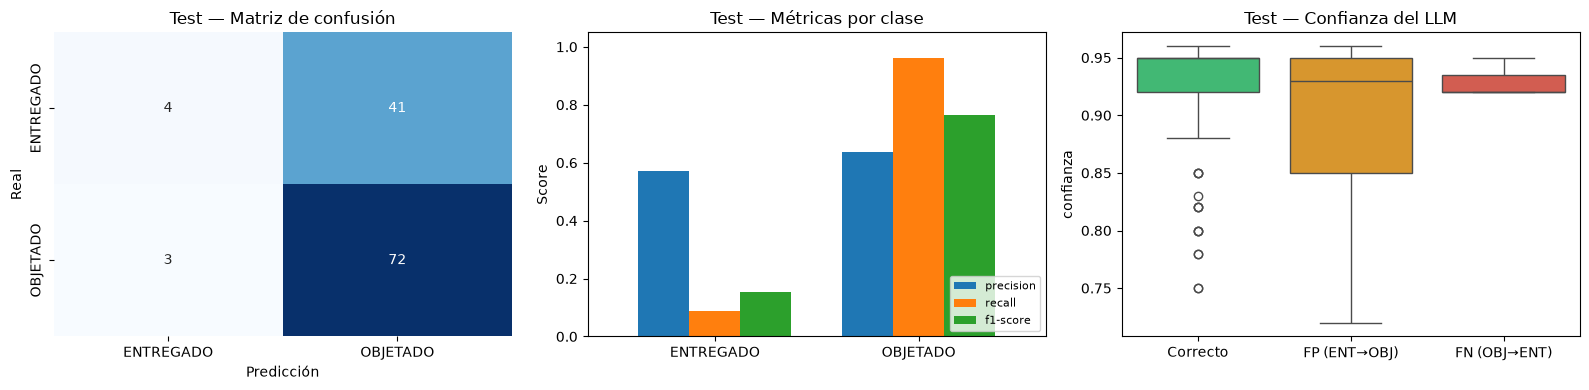

In [25]:
plot_rag_evaluation(test_results, "Test")

#### Análisis de errores (repetición validation)

Las celdas siguientes repiten FN y FP sobre `val_results` (mismo filtro que en validation).

In [30]:
# Falsos negativos: OBJETADO real → predijo ENTREGADO
fn = test_results[
    (test_results["dictamen_real"] == "OBJETADO")
    & (test_results["dictamen_pred"] == "ENTREGADO")
]
display(fn)

,numero_aviso,dictamen_real,dictamen_pred,confianza,razones,casos_similares
9,287240,OBJETADO,ENTREGADO,0.95,Relato coherente con las piezas afectadas: vue...,"223709, 267313, 271207, 297588, 187531, 205170..."
73,186691,OBJETADO,ENTREGADO,0.92,Versión de hechos coherente con las piezas afe...,"109193, 162971, 249743, 202927, 249891, 101294..."
114,216133,OBJETADO,ENTREGADO,0.92,Versión coherente: se describe impacto contra ...,"213697, 199394, 191400, 129010, 175898, 180915..."


In [31]:
fp = test_results[
    (test_results["dictamen_real"] == "ENTREGADO")
    & (test_results["dictamen_pred"] == "OBJETADO")
]
display(fp)

,numero_aviso,dictamen_real,dictamen_pred,confianza,razones,casos_similares
0,161944,ENTREGADO,OBJETADO,0.82,Mención de tercero responsable (causal 121) y ...,"181623, 191803, 169188, 98451, 176970, 173424,..."
7,237958,ENTREGADO,OBJETADO,0.80,Versión escueta y poco detallada: 'al mover re...,"242225, 248917, 234887, 226680, 244229, 238173..."
8,238185,ENTREGADO,OBJETADO,0.95,Patrón del siniestro: colisión con perro (choq...,"186306, 290098, 251403, 278564, 131181, 140894..."
10,160682,ENTREGADO,OBJETADO,0.93,Inconsistencia entre relato y piezas: versión ...,"121935, 175842, 147542, 141411, 207883, 99755,..."
12,296601,ENTREGADO,OBJETADO,0.85,Patrón de siniestro (colisión en reversa / est...,"278235, 281144, 183171, 250356, 290098, 181410..."
13,200326,ENTREGADO,OBJETADO,0.95,Inconsistencia clara entre versión de hechos y...,"101723, 115760, 228557, 175898, 115975, 152086..."
14,286755,ENTREGADO,OBJETADO,0.94,Relato vago e incompleto: el asegurado no sabe...,"170077, 277662, 274713, 214777, 235888, 232054..."
16,248465,ENTREGADO,OBJETADO,0.82,Inconsistencia entre versión y piezas: relato ...,"110027, 87669, 76221, 186068, 202702, 141411, ..."
22,213549,ENTREGADO,OBJETADO,0.93,Mención explícita de tercero responsable (otro...,"241108, 231175, 234887, 290098, 251403, 290593..."
24,216525,ENTREGADO,OBJETADO,0.92,Mención de actuación de terceros (intento de r...,"300790, 267313, 238018, 223527, 260097, 274713..."


### 4.5 Persistencia de predicciones

Guarda resultados en CSV para recalcular métricas **sin volver a llamar al LLM**.

In [18]:
val_results.to_csv("data/val_predictions.csv", index=False)
test_results.to_csv("data/test_predictions.csv", index=False)

### 4.6 Métricas — validation y test

Tablas de precision, recall y F1 por conjunto. Se cargan desde CSV si reiniciaste el kernel.

In [19]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

val_results = pd.read_csv("data/val_predictions.csv")
test_results = pd.read_csv("data/test_predictions.csv")

def print_metrics(df, name):
    y_true = df["dictamen_real"]
    y_pred = df["dictamen_pred"]
    print(f"\n=== {name} ({len(df)} casos) ===")
    print("Matriz [ENTREGADO, OBJETADO]:",
          confusion_matrix(y_true, y_pred, labels=["ENTREGADO", "OBJETADO"]).tolist())
    print(classification_report(y_true, y_pred, labels=["ENTREGADO", "OBJETADO"], zero_division=0))

print_metrics(val_results, "Val")
print_metrics(test_results, "Test")


=== Val (121 casos) ===
Matriz [ENTREGADO, OBJETADO]: [[5, 40], [2, 74]]
              precision    recall  f1-score   support

   ENTREGADO       0.71      0.11      0.19        45
    OBJETADO       0.65      0.97      0.78        76

    accuracy                           0.65       121
   macro avg       0.68      0.54      0.49       121
weighted avg       0.67      0.65      0.56       121


=== Test (120 casos) ===
Matriz [ENTREGADO, OBJETADO]: [[4, 41], [3, 72]]
              precision    recall  f1-score   support

   ENTREGADO       0.57      0.09      0.15        45
    OBJETADO       0.64      0.96      0.77        75

    accuracy                           0.63       120
   macro avg       0.60      0.52      0.46       120
weighted avg       0.61      0.63      0.54       120



#### Gráficas — comparación val vs test

Contrasta recall/precision de OBJETADO y el conteo de FN (riesgo) vs FP (conservador) entre splits.

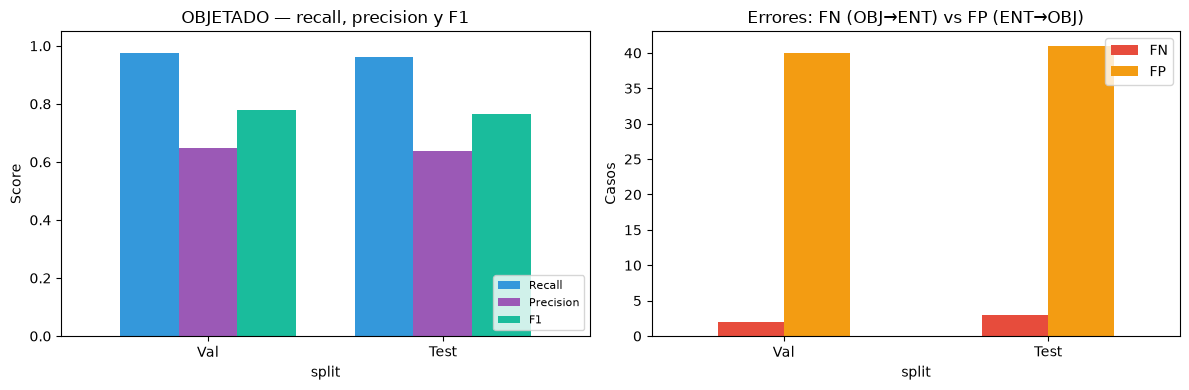

,split,recall_obj,precision_obj,f1_obj,fn,fp
0,Val,0.973684,0.649123,0.778947,2,40
1,Test,0.960000,0.637168,0.765957,3,41


In [26]:
LABELS = ["ENTREGADO", "OBJETADO"]


def _split_summary(df: pd.DataFrame, name: str) -> dict:
    y_true, y_pred = df["dictamen_real"], df["dictamen_pred"]
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    report = classification_report(
        y_true, y_pred, labels=LABELS, output_dict=True, zero_division=0
    )
    return {
        "split": name,
        "recall_obj": report["OBJETADO"]["recall"],
        "precision_obj": report["OBJETADO"]["precision"],
        "f1_obj": report["OBJETADO"]["f1-score"],
        "fn": int(cm[1, 0]),
        "fp": int(cm[0, 1]),
    }


cmp = pd.DataFrame([_split_summary(val_results, "Val"), _split_summary(test_results, "Test")])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cmp.set_index("split")[["recall_obj", "precision_obj", "f1_obj"]].plot(
    kind="bar", ax=axes[0], rot=0, width=0.75, color=["#3498db", "#9b59b6", "#1abc9c"]
)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Score")
axes[0].set_title("OBJETADO — recall, precision y F1")
axes[0].legend(["Recall", "Precision", "F1"], loc="lower right", fontsize=8)

cmp.set_index("split")[["fn", "fp"]].plot(
    kind="bar", ax=axes[1], rot=0, width=0.5, color=["#e74c3c", "#f39c12"]
)
axes[1].set_ylabel("Casos")
axes[1].set_title("Errores: FN (OBJ→ENT) vs FP (ENT→OBJ)")
axes[1].legend(["FN", "FP"], loc="upper right")

plt.tight_layout()
plt.show()
cmp

### 4.7 Resumen global (val + test)

Métricas sobre los 241 avisos unidos y listado de FN/FP globales.

In [ ]:
all_results = pd.concat([val_results, test_results], ignore_index=True)

# Métricas globales (opcional)
print_metrics(all_results, "Val + Test")

# FN/FP sobre el conjunto unido
fn = all_results[
    (all_results["dictamen_real"] == "OBJETADO")
    & (all_results["dictamen_pred"] == "ENTREGADO")
]
fp = all_results[
    (all_results["dictamen_real"] == "ENTREGADO")
    & (all_results["dictamen_pred"] == "OBJETADO")
]
display(fn,fp)


=== Val + Test (241 casos) ===
Matriz [ENTREGADO, OBJETADO]: [[9, 81], [5, 146]]
              precision    recall  f1-score   support

   ENTREGADO       0.64      0.10      0.17        90
    OBJETADO       0.64      0.97      0.77       151

    accuracy                           0.64       241
   macro avg       0.64      0.53      0.47       241
weighted avg       0.64      0.64      0.55       241



#### Gráficas — resumen global (val + test)

Vista agregada sobre los 241 avisos evaluados.  
Si reiniciaste el kernel, ejecuta antes la celda **Gráficas — validation** (define `plot_rag_evaluation`).

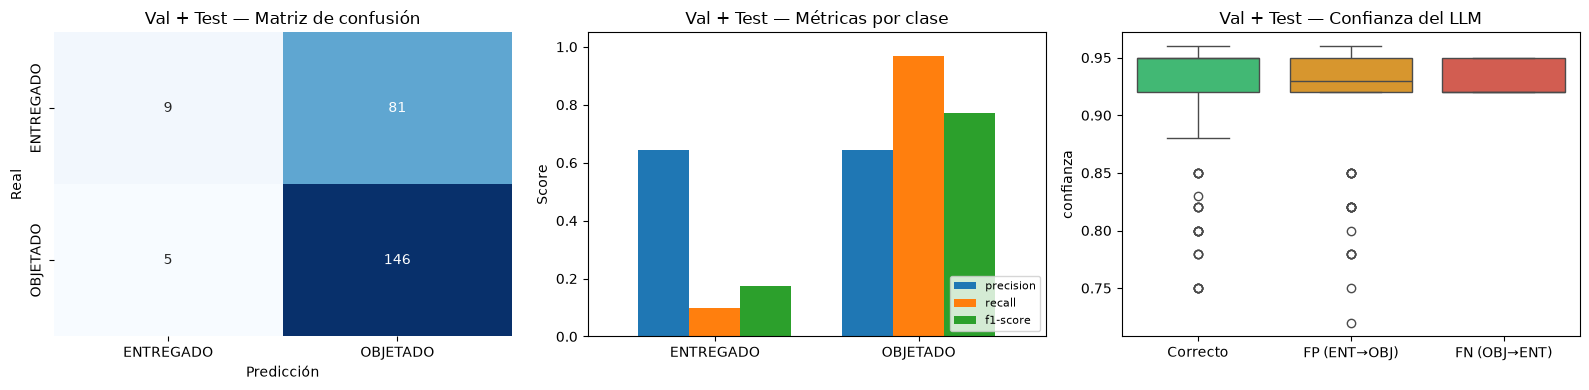

In [27]:
plot_rag_evaluation(all_results, "Val + Test")